In [ ]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def initialize_earth_engine(project_id):
    try:
        # Initialize Earth Engine with the provided project ID
        ee.Authenticate()
        ee.Initialize(project=project_id)
        print(f"Earth Engine initialized with project: {project_id}")
    except Exception as e:
        print(f"Error initializing Earth Engine: {e}")
        print("Trying to authenticate first...")
        ee.Authenticate()
        ee.Initialize(project=project_id)
        print("Earth Engine initialized after authentication")

# Set parameters for the analysis
project_id = "musa-wildfire-449918"
asset_path = "projects/musa-wildfire-449918/assets/angola_training_1000m_2020_updated"

# Initialize Earth Engine
initialize_earth_engine(project_id)

# Load the Angola dataset
MBraster = ee.Image(asset_path)

Earth Engine initialized with project: musa-wildfire-449918


In [ ]:
# Check the original bands
band_name = MBraster.bandNames().getInfo()
print(f"Original bands: {band_name}")

Original bands: ['eco-regions', 'pdsi', 'tmmx', 'vs', 'soil', 'pr', 'BurnDate', 'BurnDate_1', 'elevation', 'agb', 'population', 'NDVI']


In [ ]:
# Create a map centered on the image
Map = geemap.Map()

vis_params = {'bands': [band_name[0]], 'min': 0, 'max': 255} # Example visualization parameters. Adjust as needed

Map.centerObject(MBraster, 6)  # Adjust zoom level as needed
Map.addLayer(MBraster, vis_params, 'MBraster')
Map


Map(center=[-11.261606013879444, 17.395873969877197], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
# Define Angola region of interest using the dataset's own geometry
roi = MBraster.geometry()

# Convert burned area to a binary raster
binary_burned = MBraster.select("BurnDate").rename("is_burned").unmask(0).gt(0)
MBraster = MBraster.addBands(binary_burned)

print(f"MBraster bands after adding is_burned: {MBraster.bandNames().getInfo()}")

MBraster bands after adding is_burned: ['eco-regions', 'pdsi', 'tmmx', 'vs', 'soil', 'pr', 'BurnDate', 'BurnDate_1', 'elevation', 'agb', 'population', 'NDVI', 'is_burned']


In [ ]:
# Ensure burned raster is binary (0 = Not Burned, 1 = Burned)
histogram = binary_burned.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=MBraster.geometry(),
    scale=1000,  # 1000m resolution for Angola dataset
    maxPixels=1e9
)

# Extract and print the result
histogram_info = histogram.getInfo()
print(f"Histogram of cell values: {histogram_info}")


Histogram of cell values: {'is_burned': {'0': 957876, '1': 142834.61960784323}}


In [ ]:

# Create an image with all explanatory variables
# Using all available environmental variables from the dataset
explanatory_vars = MBraster.select(['pdsi', 'tmmx', 'vs', 'soil', 'pr', 'elevation', 'agb', 'population', 'NDVI'])
input_image = explanatory_vars.addBands(binary_burned)

print(f"Input image bands: {input_image.bandNames().getInfo()}")

Input image bands: ['pdsi', 'tmmx', 'vs', 'soil', 'pr', 'elevation', 'agb', 'population', 'NDVI', 'is_burned']


In [ ]:
input_image

In [ ]:
# Sample from the combined image
samples = input_image.stratifiedSample(
    numPoints=3000,
    classBand='is_burned',
    region=roi,
    scale=1000,  # Match the scale to the dataset resolution
    seed=42,
    geometries=True,
    classValues=[0, 1],  # Explicitly specify the class values
    classPoints=[1500, 1500]  # Equal number of points from each class
)

# Print sample size to verify
print(f"Sample size: {samples.size().getInfo()}")


Sample size: 3000


In [ ]:
# Check class distribution in samples
sample_histogram = samples.aggregate_histogram('is_burned').getInfo()
print(f"Sample class distribution: {sample_histogram}")

# Additional verification - sample a few points to check if they have all properties
sample_features = samples.limit(5).getInfo()
print("Example of sample features:")
for i, feature in enumerate(sample_features['features']):
    print(f"Sample {i+1} properties: {feature['properties']}")

Sample class distribution: {'0': 1500, '1': 1500}
Example of sample features:
Sample 1 properties: {'NDVI': 0.5173173342262466, 'agb': 5.795100212097168, 'elevation': 1245, 'is_burned': 0, 'pdsi': 340, 'population': 5.107962, 'pr': 0.25, 'soil': 304.75, 'tmmx': 279.5, 'vs': 242.5}
Sample 2 properties: {'NDVI': 0.6989787599028794, 'agb': 46.53987503051758, 'elevation': 1674, 'is_burned': 0, 'pdsi': 248.25, 'population': 2.711548, 'pr': 11.5, 'soil': 330.5, 'tmmx': 253.75, 'vs': 245}
Sample 3 properties: {'NDVI': 0.6036522178041106, 'agb': 6.628224849700928, 'elevation': 1396, 'is_burned': 0, 'pdsi': 382.75, 'population': 3.845452, 'pr': 19, 'soil': 367.75, 'tmmx': 264, 'vs': 227.5}
Sample 4 properties: {'NDVI': 0.6366724731544358, 'agb': 26.42085075378418, 'elevation': 1409, 'is_burned': 0, 'pdsi': 257.5, 'population': 5.232895, 'pr': 0.25, 'soil': 227.5, 'tmmx': 265.5, 'vs': 252.5}
Sample 5 properties: {'NDVI': 0.3726723514950158, 'agb': 6.957250118255615, 'elevation': 1177, 'is_burned

In [ ]:
# Split data for training and validation
validation = samples.randomColumn('random')
training_set = validation.filter(ee.Filter.lt('random', 0.7))
testing_set = validation.filter(ee.Filter.gte('random', 0.7))

# Print split sizes to verify
print(f"Training set size: {training_set.size().getInfo()}")
print(f"Testing set size: {testing_set.size().getInfo()}")


Training set size: 2119
Testing set size: 881


In [ ]:

# Train the classifier - Using probability output mode
change_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    variablesPerSplit=3,
    minLeafPopulation=5,
    bagFraction=0.7,
    seed=42
).setOutputMode('PROBABILITY').train(
    features=training_set,
    classProperty='is_burned',
    inputProperties=explanatory_vars.bandNames()
)

# Apply the classifier to get probability of burning
probability_image = explanatory_vars.classify(change_classifier)

# Get probability scores for testing set evaluation
test_with_prob = testing_set.classify(change_classifier)


In [ ]:

# Create a map for visualization
Map = geemap.Map()

# Add the original binary ground truth
binary_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['ffffff', 'ff0000']  # White = not burned (0), Red = burned (1)
}
Map.addLayer(MBraster.select('is_burned'), binary_vis_params, 'Ground Truth Burned Area')

# Add the probability layer with a continuous color palette
probability_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['ffffff', 'ffff00', 'ff9900', 'ff0000']  # White → Yellow → Orange → Red
}
Map.addLayer(probability_image, probability_vis_params, 'Wildfire Probability')

# Create a threshold-based layer
threshold = 0.5
predicted_binary = probability_image.gt(threshold)
Map.addLayer(predicted_binary, binary_vis_params, 'Predicted Binary (threshold=' + str(threshold) + ')')

# Add a difference layer to visualize model performance
difference = predicted_binary.neq(MBraster.select('is_burned'))
difference_vis_params = {
    'min': 0,
    'max': 1,
    'palette': ['00ff00', '0000ff']  # Green = correct, Blue = incorrect
}
Map.addLayer(difference, difference_vis_params, 'Prediction Errors')

# Center the map on Angola
Map.centerObject(roi, zoom=6)  # Adjust zoom level as needed for Angola

# Add legend
legend_dict = {
    'Ground Truth: Burned': 'ff0000',
    'Ground Truth: Not Burned': 'ffffff',
    'High Fire Probability': 'ff0000',
    'Medium Fire Probability': 'ff9900',
    'Low Fire Probability': 'ffff00',
    'Very Low Fire Probability': 'ffffff',
    'Correct Prediction': '00ff00',
    'Incorrect Prediction': '0000ff'
}
Map.add_legend(title="Wildfire Map Legend", legend_dict=legend_dict)

# Display the map
display(Map)  # For notebook environments


Map(center=[-11.261606013879444, 17.395873969877197], controls=(WidgetControl(options=['position', 'transparen…

Example probability predictions:
Sample 1: True class = 0, Predicted probability = 0.03856856846549797
Sample 2: True class = 0, Predicted probability = 0.6222111943786321
Sample 3: True class = 0, Predicted probability = 0.26628939328867696
Sample 4: True class = 0, Predicted probability = 0.6829783764170168
Sample 5: True class = 0, Predicted probability = 0.6134747337629004
Confusion Matrix: [[300, 130], [108, 343]]
Overall Accuracy: 0.7298524404086265
Precision: 0.7252
Recall (Sensitivity): 0.7605
Specificity: 0.6977
F1 Score: 0.7424
Balanced Accuracy: 0.7291
Feature importance: {'NDVI': 93.95780804083539, 'agb': 85.20701707142841, 'elevation': 91.01068212815072, 'pdsi': 86.87318271956879, 'population': 41.717038528643464, 'pr': 71.32394136943861, 'soil': 104.45133464249939, 'tmmx': 79.13425604434825, 'vs': 41.7809648930341}

Feature importance ranking:
1. soil: 104.45133464249939
2. NDVI: 93.95780804083539
3. elevation: 91.01068212815072
4. pdsi: 86.87318271956879
5. agb: 85.20701

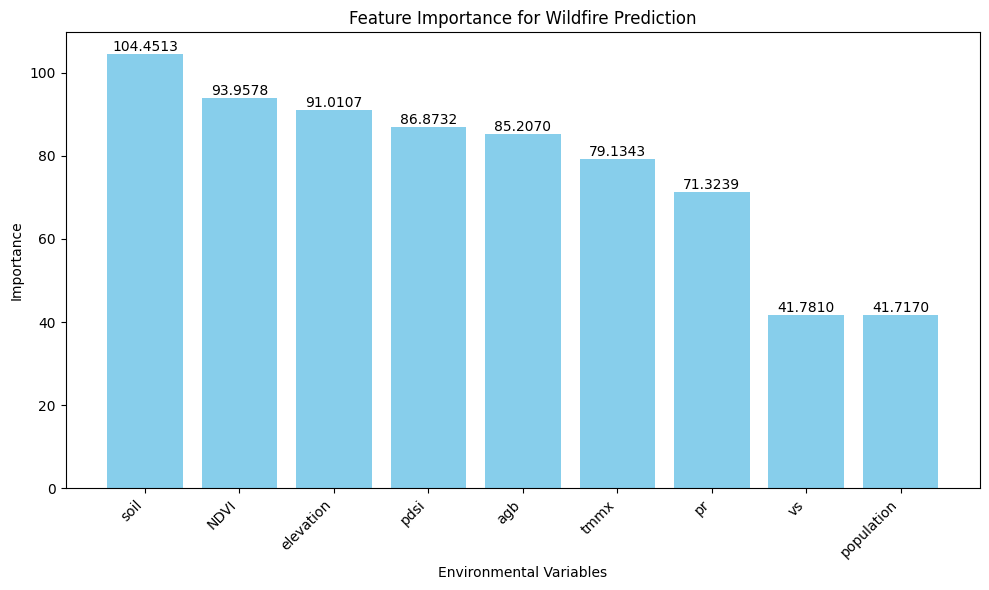

In [ ]:

# Model evaluation
# Examine sample probabilities
sample_probs = test_with_prob.limit(5).getInfo()
print("Example probability predictions:")
for i, feature in enumerate(sample_probs['features']):
    print(f"Sample {i+1}: True class = {feature['properties']['is_burned']}, "
          f"Predicted probability = {feature['properties']['classification']}")

# Create a binary classifier for evaluation metrics
binary_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=100,
    variablesPerSplit=3,
    minLeafPopulation=5,
    bagFraction=0.7,
    seed=42
).train(
    features=training_set,
    classProperty='is_burned',
    inputProperties=explanatory_vars.bandNames()
)

# Classify the test set with binary predictions
test_results = testing_set.classify(binary_classifier)

# Calculate confusion matrix and accuracy
confusion_matrix = test_results.errorMatrix('is_burned', 'classification')
print(f"Confusion Matrix: {confusion_matrix.getInfo()}")
print(f"Overall Accuracy: {confusion_matrix.accuracy().getInfo()}")

# Calculate additional metrics
cm_array = confusion_matrix.getInfo()
if len(cm_array) >= 2 and len(cm_array[0]) >= 2:
    TP = cm_array[1][1]  # True Positives
    FP = cm_array[0][1]  # False Positives
    FN = cm_array[1][0]  # False Negatives
    TN = cm_array[0][0]  # True Negatives

    # Calculate precision and recall
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # Calculate specificity
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Calculate F1 score
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Calculate balanced accuracy
    balanced_acc = (recall + specificity) / 2

    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Get feature importance
try:
    # Using explain() method
    explained = change_classifier.explain()
    importance_values = explained.get('importance').getInfo()
    band_names = explanatory_vars.bandNames().getInfo()

    # Check if importance_values is a dictionary with band names as keys
    if isinstance(importance_values, dict):
        band_importance = importance_values
    else:
        # If it's a list or has a different structure, create the dict properly
        band_importance = {}
        for i, band in enumerate(band_names):
            if isinstance(importance_values, list) and i < len(importance_values):
                band_importance[band] = importance_values[i]
            else:
                # If there's an issue with the structure, assign default values
                band_importance[band] = 0

    print(f"Feature importance: {band_importance}")

    # Handle the case where values might be strings
    numeric_importance = {}
    for band, value in band_importance.items():
        if isinstance(value, str):
            # We need to manually map the band names to numeric values
            # This is a workaround since the explain() method seems to return band names instead of values
            numeric_importance[band] = 1.0 / (band_names.index(value) + 1)  # Assigning inverse rank as importance
        else:
            numeric_importance[band] = float(value)

    # Sort by the numeric values
    sorted_importance = sorted(numeric_importance.items(), key=lambda x: x[1], reverse=True)

    print("\nFeature importance ranking:")
    for i, (feature, importance) in enumerate(sorted_importance):
        print(f"{i+1}. {feature}: {importance}")

    # Create a bar chart with the numeric values
    features = [item[0] for item in sorted_importance]
    values = [item[1] for item in sorted_importance]

    plt.figure(figsize=(10, 6))
    bars = plt.bar(features, values, color='skyblue')
    plt.xlabel('Environmental Variables')
    plt.ylabel('Importance')
    plt.title('Feature Importance for Wildfire Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', rotation=0)

    plt.show()

except Exception as e:
    print(f"Error processing feature importance: {e}")
    print("Attempting alternative feature importance calculation...")

    # Alternative feature importance calculation using variable importance scores
    # We'll use a simpler approach by calculating accuracy for each variable individually
    importance_scores = {}

    for band in explanatory_vars.bandNames().getInfo():
        try:
            # Train a single-feature classifier
            single_var_classifier = ee.Classifier.smileRandomForest(
                numberOfTrees=50,
                seed=42
            ).train(
                features=training_set,
                classProperty='is_burned',
                inputProperties=[band]
            )

            # Test it
            single_var_results = testing_set.classify(single_var_classifier)

            # Calculate accuracy
            single_var_cm = single_var_results.errorMatrix('is_burned', 'classification')
            accuracy = single_var_cm.accuracy().getInfo()

            importance_scores[band] = accuracy
        except Exception as e2:
            print(f"Error calculating importance for {band}: {e2}")
            importance_scores[band] = 0.0

    # Sort by importance
    sorted_importance = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

    print("\nAlternative feature importance ranking:")
    for i, (feature, importance) in enumerate(sorted_importance):
        print(f"{i+1}. {feature}: {importance:.4f}")

    # Create a bar chart with the numeric values
    features = [item[0] for item in sorted_importance]
    values = [item[1] for item in sorted_importance]

    # plt.figure(figsize=(10, 6))
    # bars = plt.bar(features, values, color='lightgreen')
    # plt.xlabel('Environmental Variables')
    # plt.ylabel('Accuracy When Used Alone')
    # plt.title('Feature Importance Based on Single-Variable Prediction Accuracy')
    # plt.xticks(rotation=45, ha='right')
    # plt.tight_layout()

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom', rotation=0)

    plt.show()


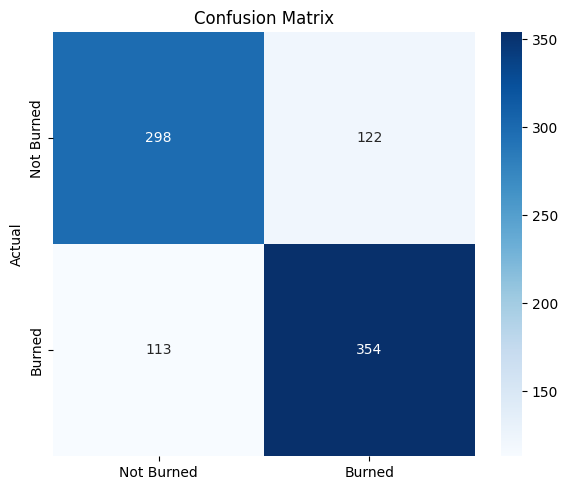

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 获取混淆矩阵数据（二维列表）
conf_matrix_array = confusion_matrix.getInfo()

# 设置你的标签（需要你自己知道分类值，比如二分类为 0 和 1）
labels = ['Not Burned', 'Burned']  # 或者 ['0', '1']，根据你的数据修改！

# 构建 DataFrame
df_cm = pd.DataFrame(conf_matrix_array, index=labels, columns=labels)

# 可视化
plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [ ]:

# Export the probability image to Earth Engine Asset
export_task = ee.batch.Export.image.toAsset(
    image=probability_image,
    description='angola_wildfire_probability',
    assetId='projects/musa-wildfire-449918/assets/angola_wildfire_probability',
    region=roi,
    scale=1000,
    maxPixels=1e9
)

# Uncomment to start the export
# export_task.start()
# print("Export task started. Check your Earth Engine tasks.")

# Export the feature importance as a CSV for further analysis
# Convert feature importance (with numeric values) for export
try:
    importance_list = []
    for band, value in numeric_importance.items():
        importance_list.append(ee.Feature(None, {'band': band, 'importance': float(value)}))

    importance_fc = ee.FeatureCollection(importance_list)

    export_importance = ee.batch.Export.table.toDrive(
        collection=importance_fc,
        description='angola_feature_importance',
        fileFormat='CSV'
    )
except NameError:
    print("Skipping importance export because numeric_importance wasn't successfully created")

# Uncomment to start the export
# export_importance.start()
# print("Feature importance export started. Check your Earth Engine tasks.")


In [ ]:

# Create a time-series visualization function if temporal data is available
def create_time_series_chart(point):
    """Generate a time series chart for a selected point"""
    # This function would need to be adapted to your specific temporal dataset
    # This is just a placeholder that would need to be modified
    print("To implement time series analysis, load a temporal dataset like:")
    print("ee.ImageCollection('MODIS/061/MCD64A1').filterBounds(roi).filterDate('2020-01-01', '2020-12-31')")

    # For demonstration, print the values at the selected point
    point_values = explanatory_vars.sample(
        region=ee.Geometry.Point(point),
        scale=1000,
        numPixels=1
    ).first().getInfo()

    print(f"Environmental variables at selected point: {point_values['properties']}")
    print(f"Predicted fire probability: {probability_image.sample(ee.Geometry.Point(point), 1000).first().get('classification').getInfo()}")

# You would call this function with a point of interest
# For example: create_time_series_chart([13.5, -12.5])  # Longitude, Latitude for a point in Angola